In [6]:

import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Read the CSV file into a DataFrame
df = pd.read_csv('data (1).csv')

# Display the first 5 rows
print(df.head().to_markdown(index=False, numalign="left", stralign="left"))

# Print the column names and their data types
print(df.info())

| Date                | Longitude   | Latitude   | Depth   | Rms   | Type   | Magnitude   | Location              | EventID   |
|:--------------------|:------------|:-----------|:--------|:------|:-------|:------------|:----------------------|:----------|
| 21/11/2025 21:22:25 | 28.9719     | 39.2458    | 5.03    | 0.58  | ML     | 3.8         | Simav (Kütahya)       | 695383    |
| 21/11/2025 17:44:20 | 26.4422     | 39.5842    | 7.02    | 0.22  | ML     | 3.2         | Ayvacık (Çanakkale)   | 695359    |
| 20/11/2025 12:32:31 | 36.6406     | 37.1592    | 4.77    | 0.66  | ML     | 3.1         | Bahçe (Osmaniye)      | 695106    |
| 20/11/2025 12:19:00 | 36.6344     | 37.1408    | 7       | 0.44  | MW     | 3.5         | Hasanbeyli (Osmaniye) | 695100    |
| 20/11/2025 12:12:44 | 28.3014     | 39.2031    | 10.09   | 0.38  | ML     | 3.2         | Sındırgı (Balıkesir)  | 695095    |
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31916 entries, 0 to 31915
Data columns (total 9 column

In [12]:
import pandas as pd
import numpy as np
import torch
import random
import os
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# --- SEED SABİTLEME KODU (Bunu Ekleyin) ---
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Random Seed {seed} olarak sabitlendi.")

seed_everything(42)


# 1. VERİYİ YÜKLEME VE FİLTRELEME
# ---------------------------------------------------------
df = pd.read_csv('data (1).csv') # Dosya adını buraya yaz

# Tarihi datetime formatına çevir
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y %H:%M:%S')

# Marmara Bölgesi Filtresi (Yaklaşık Koordinatlar)
# Enlem: 39.0 - 42.0, Boylam: 26.0 - 32.0
df = df[(df['Latitude'] >= 39.0) & (df['Latitude'] <= 42.0) & 
        (df['Longitude'] >= 26.0) & (df['Longitude'] <= 32.0)]

# Büyüklük Filtresi (3.0 ve üzeri - Gürültüyü azaltmak için)
df = df[df['Magnitude'] >= 3.0]

# Tarihe göre eskiden yeniye sırala (Zaman serisi için kritik!)
df = df.sort_values(by='Date').reset_index(drop=True)

# Tarihi modele sokabilmek için sayısal değere (Timestamp) çeviriyoruz
df['Timestamp'] = df['Date'].astype('int64') // 10**9

# Kullanacağımız özellikler (Girdiler)
features = ['Latitude', 'Longitude', 'Depth', 'Timestamp', 'Magnitude']
data = df[features].values

# Veriyi 0 ile 1 arasına sıkıştır (Normalizasyon - LSTM için şarttır)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

print(f"İşlenen veri boyutu: {data_scaled.shape}")
print("Veri hazırlığı tamam!")

Random Seed 42 olarak sabitlendi.
İşlenen veri boyutu: (8417, 5)
Veri hazırlığı tamam!


In [9]:
# 2. SLIDING WINDOW (PENCERELEME)
# ---------------------------------------------------------
def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)] # Geçmiş 10 deprem (Tüm özellikler)
        y = data[i + seq_length, -1] # Sıradaki depremin SADECE Büyüklüğü (Magnitude)
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

SEQ_LENGTH = 10 # Geçmiş kaç depreme bakacağı
X, y = create_sequences(data_scaled, SEQ_LENGTH)

# Veriyi Train (%80) ve Test (%20) olarak ayır
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# PyTorch Tensorlarına çevir
X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).float()
X_test = torch.from_numpy(X_test).float()
y_test = torch.from_numpy(y_test).float()

print(f"Eğitim Seti Boyutu: {X_train.shape}")
print(f"Test Seti Boyutu: {X_test.shape}")

Eğitim Seti Boyutu: torch.Size([6725, 10, 5])
Test Seti Boyutu: torch.Size([1682, 10, 5])


In [10]:
# 3. GRU MODEL MİMARİSİ
# ---------------------------------------------------------
import torch
import torch.nn as nn

class EarthquakeGRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers):
        super(EarthquakeGRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # GRU Katmanı
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        
        # Çıktı Katmanı
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # GRU sadece h0 kullanır
        out, _ = self.gru(x, h0)
        
        out = out[:, -1, :]
        out = self.fc(out)
        return out

# Model Parametrelerini Tekrar Tanımlıyoruz (Silindiği için hata veriyordu)
input_size = 5    # (Enlem, Boylam, Derinlik, Zaman, Büyüklük)
hidden_size = 64  # Nöron sayısı
num_layers = 2    # Katman sayısı
output_size = 1   # Çıktı boyutu

# Modeli Başlat
model = EarthquakeGRU(input_size, hidden_size, output_size, num_layers)
print("✅ GRU Modeli Başarıyla Oluşturuldu!")
print(model)

✅ GRU Modeli Başarıyla Oluşturuldu!
EarthquakeGRU(
  (gru): GRU(5, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


Eğitim Başlıyor...
Epoch: 10/50, Train Loss: 0.00709, Test Loss: 0.01242
Epoch: 20/50, Train Loss: 0.00704, Test Loss: 0.01346
Epoch: 30/50, Train Loss: 0.00683, Test Loss: 0.01297
Epoch: 40/50, Train Loss: 0.00668, Test Loss: 0.01235
Epoch: 50/50, Train Loss: 0.00649, Test Loss: 0.01154


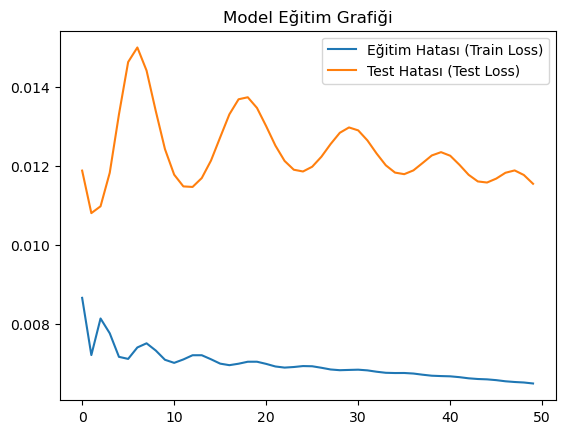

In [11]:
# 4. EĞİTİM DÖNGÜSÜ (TRAINING LOOP)
# ---------------------------------------------------------
learning_rate = 0.001
num_epochs = 50 # Eğitim tur sayısı

loss_fn = nn.MSELoss() # Hata fonksiyonu (Mean Squared Error)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

train_losses = []
test_losses = []

print("Eğitim Başlıyor...")
for epoch in range(num_epochs):
    model.train()
    outputs = model(X_train)
    optimizer.zero_grad()
    
    # Hatayı hesapla
    loss = loss_fn(outputs, y_train.unsqueeze(1))
    
    # Geri yayılım (Backpropagation)
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    # Test seti ile doğrulama (Validation)
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test)
        test_loss = loss_fn(test_outputs, y_test.unsqueeze(1))
        test_losses.append(test_loss.item())
    
    if (epoch+1) % 10 == 0:
        print(f'Epoch: {epoch+1}/{num_epochs}, Train Loss: {loss.item():.5f}, Test Loss: {test_loss.item():.5f}')

# Kayıp (Loss) Grafiğini Çiz (Raporun Appendix kısmına koyarsın)
plt.plot(train_losses, label='Eğitim Hatası (Train Loss)')
plt.plot(test_losses, label='Test Hatası (Test Loss)')
plt.legend()
plt.title("Model Eğitim Grafiği")
plt.show()